<a href="https://colab.research.google.com/github/Sukhleen321/runway-vision/blob/main/runway_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

# Unzip once (takes 2-5 mins for 11GB)
zip_path = '/content/drive/MyDrive/archive.zip'
extract_to = '/content/dataset'

if not os.path.exists(extract_to):
    os.makedirs(extract_to)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print("✅ Unzipped!")

# List top-level contents
print("\n📁 Dataset contents:")
for item in os.listdir(extract_to)[:10]:  # show first 10
    print(item)

✅ Unzipped!

📁 Dataset contents:
640x360
1920x1080
labels


In [ ]:
import cv2
import numpy as np
import torch
from pathlib import Path
import os
import json
import torchvision.transforms as T


# 🔧 CONFIG — CORRECTED PATHS
IMAGE_DIR = '/content/dataset/640x360/640x360'
LABEL_DIR = '/content/dataset/labels'
OUTPUT_DIR = '/content/processed'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load JSONs
train_json = '/content/dataset/labels/labels/lines/train_labels_640x360.json'
test_json = '/content/dataset/labels/labels/lines/test_labels_640x360.json'

all_annotations = {}
for json_path in [train_json, test_json]:
    if os.path.exists(json_path):
        with open(json_path, 'r') as f:
            data = json.load(f)
            all_annotations.update(data)

print(f"📊 Total labeled images: {len(all_annotations)}")

# Extract anchors WITH NORMALIZATION (640x360 → [0,1])
anchor_dict = {}
for img_name, ann_list in all_annotations.items():
    ledg = redg = ctl = None
    for ann in ann_list:
        label = ann.get('label')
        pts = ann.get('points', [])
        if len(pts) == 2 and label in ['LEDG', 'REDG', 'CTL']:
            if label == 'LEDG': ledg = pts
            elif label == 'REDG': redg = pts
            elif label == 'CTL': ctl = pts
    if ledg and redg and ctl:
        anchors = [
            ledg[0][0] / 640.0, ledg[0][1] / 360.0,
            ledg[1][0] / 640.0, ledg[1][1] / 360.0,
            redg[0][0] / 640.0, redg[0][1] / 360.0,
            redg[1][0] / 640.0, redg[1][1] / 360.0,
            ctl[0][0] / 640.0, ctl[0][1] / 360.0,
            ctl[1][0] / 640.0, ctl[1][1] / 360.0
        ]
        anchor_dict[img_name] = anchors

print(f"✅ Images with all 3 lines: {len(anchor_dict)}")

# Build image map: {stem → full_path} — RECURSIVE + EXTENSION AGNOSTIC
image_stem_to_path = {}
for root, _, files in os.walk(IMAGE_DIR):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            stem = Path(f).stem
            image_stem_to_path[stem] = os.path.join(root, f)

print(f"✅ Found {len(image_stem_to_path)} images in {IMAGE_DIR}")

# Build mask map: {filename (with ext) → full_path}
mask_name_to_path = {}
for root, _, files in os.walk(LABEL_DIR):
    for f in files:
        if f.lower().endswith('.png'):
            mask_name_to_path[f] = os.path.join(root, f)

print(f"✅ Found {len(mask_name_to_path)} mask files")

# Match samples
valid_samples = []
for json_name in anchor_dict.keys():
    # Match image by stem
    json_stem = Path(json_name).stem
    if json_stem not in image_stem_to_path:
        continue

    # Match mask by full name (json_name is like 'xxx.png')
    if json_name not in mask_name_to_path:
        print(f"⚠️ Mask not found: {json_name}")
        continue

    valid_samples.append((json_name, image_stem_to_path[json_stem], mask_name_to_path[json_name]))

print(f"✅ Found {len(valid_samples)} valid image-mask-label triplets")

# Preprocess
processed = 0
for json_name, img_path, mask_path in valid_samples:
    # Load image
    img = cv2.imread(img_path)
    if img is None:
        continue

    # ✅ FIX: Load mask as RGB and extract RED channel (runway = red)
    mask_rgb = cv2.imread(mask_path)
    if mask_rgb is None:
        continue
    # OpenCV is BGR, so red = channel 2
    mask_binary = (mask_rgb[:, :, 2] > 127).astype(np.uint8) * 255  # 0 or 255

    # Optional: Verify mask has runway
    if mask_binary.sum() == 0:
        print(f"⚠️ Empty mask (no red pixels): {json_name}")
        continue

    # Resize to 256x256
    img_small = cv2.resize(img, (256, 256), interpolation=cv2.INTER_AREA)
    mask_small = cv2.resize(mask_binary, (256, 256), interpolation=cv2.INTER_NEAREST)

    # Tensors
    img_tensor = torch.from_numpy(img_small).permute(2, 0, 1).float() / 255.0
    mask_tensor = torch.from_numpy((mask_small > 127).astype(np.float32))  # binary 0/1
    anchor_tensor = torch.tensor(anchor_dict[json_name], dtype=torch.float32)

    # Save
    output_name = Path(img_path).stem
    torch.save({
        'image': img_tensor,
        'mask': mask_tensor,
        'anchors': anchor_tensor,
        'name': output_name
    }, os.path.join(OUTPUT_DIR, f"{output_name}.pt"))

    processed += 1
    if processed % 500 == 0:
        print(f"✅ Processed {processed}/{len(valid_samples)}")

print(f"\n🎉 Preprocessing complete! Saved {processed} samples to {OUTPUT_DIR}")

📊 Total labeled images: 5587
✅ Images with all 3 lines: 4889
✅ Found 5587 images in /content/dataset/640x360/640x360
✅ Found 5587 mask files
✅ Found 4889 valid image-mask-label triplets
⚠️ Empty mask (no red pixels): VHHH25R2_9FNLImage5.png
✅ Processed 500/4889
✅ Processed 1000/4889
✅ Processed 1500/4889
✅ Processed 2000/4889
✅ Processed 2500/4889
✅ Processed 3000/4889
✅ Processed 3500/4889
✅ Processed 4000/4889
✅ Processed 4500/4889

🎉 Preprocessing complete! Saved 4888 samples to /content/processed


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models
from pathlib import Path
import pandas as pd
import os
from shapely.geometry import Point, Polygon
import numpy as np

# CONFIG
PROCESSED_DIR = '/content/processed'
BATCH_SIZE = 32
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

class RunwayDataset(Dataset):
    def __init__(self, processed_dir):
        self.files = [os.path.join(processed_dir, f) for f in os.listdir(processed_dir) if f.endswith('.pt')]
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        data = torch.load(self.files[idx])
        return data['image'], data['mask'], data['anchors'], data['name']

class RunwayNet(nn.Module):
    def __init__(self):
        super().__init__()
        # MobileNetV3 backbone (final features: [B, 960, 8, 8] for 256x256 input)
        backbone = models.mobilenet_v3_large(weights="IMAGENET1K_V1")
        self.features = backbone.features

        # Decoder for segmentation mask
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(960, 256, kernel_size=4, stride=2, padding=1),  # 8 -> 16
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # 16 -> 32
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),   # 32 -> 64
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),    # 64 -> 128
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),    # 128 -> 256
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=1)  # final 1-channel mask
        )

        # Regression head (for 12 anchor points: LEDG, REDG, CTL endpoints)
        self.regressor = nn.Sequential(
            nn.Conv2d(960, 128, kernel_size=1),   # shrink channels, keep the 8x8 spatial map
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Flatten(),                          # 128*8*8 = 8192
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 12),
            nn.Sigmoid()                           # bounds output to [0,1] — matches your normalized labels
        )

    def forward(self, x):
        feats = self.features(x)              # [B, 960, 8, 8]
        seg = self.decoder(feats).squeeze(1)   # [B, 256, 256]
        anchors = self.regressor(feats)        # [B, 12]
        return seg, anchors

def dice_loss(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred)
    intersection = (pred * target).sum()
    return 1 - (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def anchor_pixel_error(pred, gt, img_w=640, img_h=360):
    # pred, gt: [B, 12] normalized coords -> denormalize and compute mean L2 distance per point
    pred = pred.clone()
    gt = gt.clone()
    pred[:, 0::2] *= img_w
    gt[:, 0::2]   *= img_w
    pred[:, 1::2] *= img_h
    gt[:, 1::2]   *= img_h
    pred_pts = pred.view(pred.shape[0], 6, 2)
    gt_pts = gt.view(gt.shape[0], 6, 2)
    return torch.norm(pred_pts - gt_pts, dim=2).mean().item()


def anchor_loss_px(pred, gt, img_w=640.0, img_h=360.0, beta=5.0):
    pred_px = pred.clone()
    gt_px = gt.clone()
    pred_px[:, 0::2] = pred_px[:, 0::2] * img_w
    gt_px[:, 0::2]   = gt_px[:, 0::2] * img_w
    pred_px[:, 1::2] = pred_px[:, 1::2] * img_h
    gt_px[:, 1::2]   = gt_px[:, 1::2] * img_h
    return nn.SmoothL1Loss(beta=beta)(pred_px, gt_px)

# ---- Dataset + Train/Val split ----
full_dataset = RunwayDataset(PROCESSED_DIR)
if len(full_dataset) == 0:
    raise ValueError("No preprocessed data found! Run the preprocessing cell successfully first.")

val_size = int(0.15 * len(full_dataset))   # ~15% held out for validation
train_size = len(full_dataset) - val_size

train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)  # reproducible split
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}")

model = RunwayNet().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

use_amp = (DEVICE == 'cuda')
if use_amp:
    scaler = torch.amp.GradScaler('cuda')
else:
    scaler = None

# ---- Train with validation each epoch ----
NUM_EPOCHS = 100

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
# call scheduler.step() at the end of each epoch, after optimizer.step()

LINE_ERR_SCALE = 50.0   # ~50px treated as the "acceptable error" scale — tune if needed
best_score = -float('inf')
best_iou = 0.0
best_err = float('inf')

print("Starting training...")
for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    total_seg_loss = 0
    total_anchor_loss = 0
    for images, masks, anchors_gt, _ in train_loader:
        images, masks, anchors_gt = images.to(DEVICE), masks.to(DEVICE), anchors_gt.to(DEVICE)
        optimizer.zero_grad()
        if use_amp:
            with torch.amp.autocast('cuda'):
                seg_out, anchor_out = model(images)
                bce = nn.BCEWithLogitsLoss()
                loss_seg = dice_loss(seg_out, masks) + bce(seg_out, masks)
                loss_anchor = anchor_loss_px(anchor_out, anchors_gt)
                loss = loss_seg + 0.05 * loss_anchor
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            seg_out, anchor_out = model(images)
            bce = nn.BCEWithLogitsLoss()
            loss_seg = dice_loss(seg_out, masks) + bce(seg_out, masks)
            loss_anchor = anchor_loss_px(anchor_out, anchors_gt)
            loss = loss_seg + 0.05 * loss_anchor
            loss.backward()
            optimizer.step()
        total_loss += loss.item()
        total_seg_loss += loss_seg.item()
        total_anchor_loss += (0.05 * loss_anchor).item()

    scheduler.step()

    # ---- Validation pass ----
    model.eval()
    val_iou_total, val_err_total, val_batches = 0.0, 0.0, 0
    with torch.no_grad():
        for images, masks, anchors_gt, _ in val_loader:
            images, masks, anchors_gt = images.to(DEVICE), masks.to(DEVICE), anchors_gt.to(DEVICE)
            seg_out, anchor_out = model(images)

            pred_mask = (torch.sigmoid(seg_out) > 0.5).float()
            intersection = (pred_mask * masks).sum(dim=(1, 2))
            union = ((pred_mask + masks) > 0).float().sum(dim=(1, 2))
            batch_iou = (intersection / (union + 1e-6)).mean().item()

            batch_err = anchor_pixel_error(anchor_out, anchors_gt)

            val_iou_total += batch_iou
            val_err_total += batch_err
            val_batches += 1

    val_iou = val_iou_total / val_batches
    val_err = val_err_total / val_batches

    # Blended score: IoU contributes positively, line error negatively.
    # Both terms are on roughly comparable scale (0-1-ish) so neither
    # metric silently dominates checkpoint selection.
    score = val_iou - (val_err / LINE_ERR_SCALE)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {total_loss/len(train_loader):.4f} "
          f"(seg: {total_seg_loss/len(train_loader):.4f}, anchor: {total_anchor_loss/len(train_loader):.4f}) | "
          f"Val IoU: {val_iou:.4f} | Val Line Error (px): {val_err:.2f} | Score: {score:.4f}")

    if score > best_score:
        best_score = score
        best_iou = val_iou
        best_err = val_err
        torch.save(model.state_dict(), "/content/runway_model_best.pth")
        print(f"  New best model saved (IoU: {val_iou:.4f}, Line Error: {val_err:.2f}px, Score: {best_score:.4f})")

torch.save(model.state_dict(), "/content/runway_model_last.pth")
print("Training complete!")
print(f"Best checkpoint -> IoU: {best_iou:.4f} | Line Error: {best_err:.2f}px")


Using device: cuda
Train samples: 4155 | Val samples: 733
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 67.8MB/s]


Starting training...
Epoch 1/100 | Train Loss: 2.5944 (seg: 0.9668, anchor: 1.6276) | Val IoU: 0.3644 | Val Line Error (px): 36.58 | Score: -0.3672
  New best model saved (IoU: 0.3644, Line Error: 36.58px, Score: -0.3672)
Epoch 2/100 | Train Loss: 1.8199 (seg: 0.7591, anchor: 1.0608) | Val IoU: 0.4176 | Val Line Error (px): 27.43 | Score: -0.1309
  New best model saved (IoU: 0.4176, Line Error: 27.43px, Score: -0.1309)
Epoch 3/100 | Train Loss: 1.5012 (seg: 0.6122, anchor: 0.8890) | Val IoU: 0.4738 | Val Line Error (px): 24.88 | Score: -0.0239
  New best model saved (IoU: 0.4738, Line Error: 24.88px, Score: -0.0239)
Epoch 4/100 | Train Loss: 1.2662 (seg: 0.4789, anchor: 0.7873) | Val IoU: 0.5000 | Val Line Error (px): 23.04 | Score: 0.0392
  New best model saved (IoU: 0.5000, Line Error: 23.04px, Score: 0.0392)
Epoch 5/100 | Train Loss: 1.0984 (seg: 0.3723, anchor: 0.7261) | Val IoU: 0.4862 | Val Line Error (px): 21.93 | Score: 0.0477
  New best model saved (IoU: 0.4862, Line Error: 21

In [ ]:
# ---- Final evaluation on the held-out validation set (using the BEST checkpoint) ----
import pandas as pd

eval_model = RunwayNet().to(DEVICE)
eval_model.load_state_dict(torch.load("/content/runway_model_best.pth", map_location=DEVICE))
eval_model.eval()

results = []
with torch.no_grad():
    for images, masks, anchors_gt, names in val_loader:
        images, masks, anchors_gt = images.to(DEVICE), masks.to(DEVICE), anchors_gt.to(DEVICE)
        seg_out, anchor_out = eval_model(images)

        for i in range(len(names)):
            pred_mask = (torch.sigmoid(seg_out[i]) > 0.5).float()
            iou = (pred_mask * masks[i]).sum() / (pred_mask + masks[i] - pred_mask * masks[i]).sum()
            iou = float(iou) if not torch.isnan(iou) else 0.0

            pred_px = anchor_out[i].cpu().numpy().copy()
            pred_px[::2] *= 640
            pred_px[1::2] *= 360

            gt_px = anchors_gt[i].cpu().numpy().copy()
            gt_px[::2] *= 640
            gt_px[1::2] *= 360

            line_err = float(np.linalg.norm(
                pred_px.reshape(6, 2) - gt_px.reshape(6, 2), axis=1
            ).mean())

            results.append({
                'Image Name': names[i],
                'IOU score': iou,
                'Line Error (px)': line_err,
            })

df_val = pd.DataFrame(results)
df_val.to_csv('/content/val_results.csv', index=False)

print(f"Held-out validation set: {len(df_val)} samples")
print(f"Mean IoU: {df_val['IOU score'].mean():.4f}")
print(f"Mean Line Error (px): {df_val['Line Error (px)'].mean():.2f}")
print("Saved per-sample results to /content/val_results.csv")


Held-out validation set: 733 samples
Mean IoU: 0.7019
Mean Line Error (px): 11.73
Saved per-sample results to /content/val_results.csv


In [ ]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# orig is RGB (we convert BGR->RGB right after cv2.imread), so these
# tuples are (R, G, B) — (0,0,255) is blue, (255,0,0) is red, etc.
LEFT_COLOR   = (0, 0, 255)   # blue
RIGHT_COLOR  = (255, 0, 0)   # red
CENTER_COLOR = (0, 255, 0)   # green

model = RunwayNet().to(DEVICE)
model.load_state_dict(torch.load('/content/runway_model_best.pth', map_location=DEVICE))
model.eval()
print("Model loaded")


def detect_runway(image_path, model, device=DEVICE, input_size=(256, 256),
                   thickness=4, verbose=False):
    """
    Run RunwayNet on a single image and return an annotated copy.

    Args:
        image_path: path to any RGB-loadable image, any resolution.
        model:      loaded RunwayNet in eval() mode.
        device:     'cuda' or 'cpu'.
        input_size: (w, h) the model expects as input — must match training (256, 256).
        thickness:  line thickness in pixels.
        verbose:    if True, prints RAW (0-1) and SCALED (pixel) anchor values.

    Returns:
        output:     (H, W, 3) RGB uint8 image with LEDG/REDG/CTL lines drawn.
        anchors_px: dict {'left','right','center'} -> (x1, y1, x2, y2) in ORIGINAL image pixels.
        seg_mask:   (H, W) binary runway mask, resized back to the original resolution.
    """
    orig_bgr = cv2.imread(image_path)
    if orig_bgr is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
    orig = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)
    h, w = orig.shape[:2]

    img_small = cv2.resize(orig, input_size, interpolation=cv2.INTER_AREA)
    img_tensor = torch.from_numpy(img_small).permute(2, 0, 1).float().unsqueeze(0) / 255.0
    img_tensor = img_tensor.to(device)

    with torch.no_grad():
        seg_out, anchor_out = model(img_tensor)

    raw = anchor_out[0].cpu().numpy().copy()
    if verbose:
        print("RAW anchor output (0-1 fraction; no sigmoid, so it can slightly overshoot):")
        print(raw)

    # --- THE FIX ---
    # Old (wrong): anchors[0::2] *= w/640   <- assumed raw was already 0-640 pixels
    # New (right): anchors[0::2] *= w       <- raw is a 0-1 fraction, scale directly
    anchors = np.clip(raw, 0.0, 1.0)   # guard against tiny overshoot past [0,1]
    anchors[0::2] *= w   # x's -> this image's actual width
    anchors[1::2] *= h   # y's -> this image's actual height

    if verbose:
        print(f"SCALED anchor output (pixels on this {w}x{h} image):")
        print(anchors)

    def clip_line(pt):
        x1, y1, x2, y2 = pt
        return (int(np.clip(x1, 0, w - 1)), int(np.clip(y1, 0, h - 1)),
                int(np.clip(x2, 0, w - 1)), int(np.clip(y2, 0, h - 1)))

    left_c   = clip_line(anchors[0:4])
    right_c  = clip_line(anchors[4:8])
    center_c = clip_line(anchors[8:12])

    seg_mask = (torch.sigmoid(seg_out[0]) > 0.5).float().cpu().numpy()
    seg_mask = cv2.resize(seg_mask, (w, h), interpolation=cv2.INTER_NEAREST)

    output = orig.copy()
    cv2.line(output, left_c[:2],   left_c[2:],   LEFT_COLOR,   thickness, cv2.LINE_AA)
    cv2.line(output, right_c[:2],  right_c[2:],  RIGHT_COLOR,  thickness, cv2.LINE_AA)
    cv2.line(output, center_c[:2], center_c[2:], CENTER_COLOR, thickness, cv2.LINE_AA)

    anchors_px = {'left': left_c, 'right': right_c, 'center': center_c}
    return output, anchors_px, seg_mask


Model loaded


RAW anchor output (0-1 fraction; no sigmoid, so it can slightly overshoot):
[0.4976517  0.5189639  0.11919714 0.9998598  0.52074504 0.5178468
 0.93300563 0.9997876  0.50909215 0.51900613 0.50600904 1.        ]
SCALED anchor output (pixels on this 1920x1080 image):
[ 955.4913   560.48096  228.8585  1079.8486   999.83044  559.2746
 1791.3708  1079.7706   977.4569   560.5266   971.53735 1080.     ]
Left edge   (x1,y1,x2,y2): (955, 560, 228, 1079)
Right edge  (x1,y1,x2,y2): (999, 559, 1791, 1079)
Center line (x1,y1,x2,y2): (977, 560, 971, 1079)


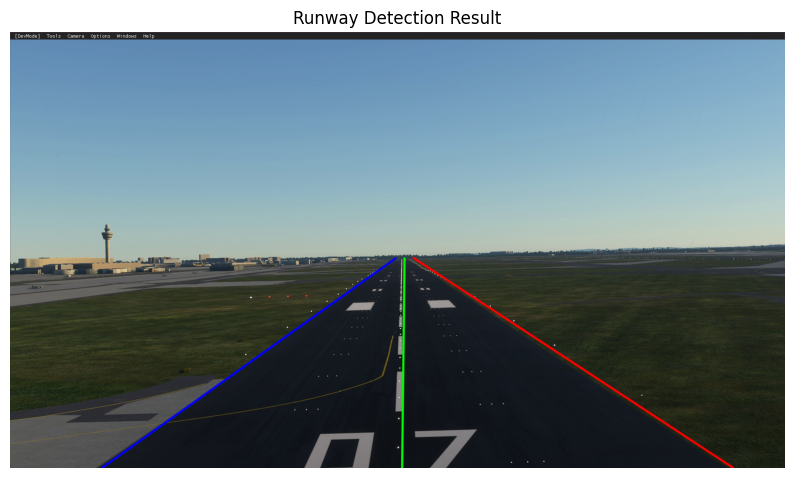

In [ ]:
# ---- Run on a sample image ----
IMAGE_PATH = '/content/sample_image.png'

output, anchors_px, seg_mask = detect_runway(IMAGE_PATH, model, verbose=True)

print("Left edge   (x1,y1,x2,y2):", anchors_px['left'])
print("Right edge  (x1,y1,x2,y2):", anchors_px['right'])
print("Center line (x1,y1,x2,y2):", anchors_px['center'])

plt.figure(figsize=(10, 6))
plt.imshow(output)
plt.axis('off')
plt.title("Runway Detection Result")
plt.show()


RAW anchor output (0-1 fraction; no sigmoid, so it can slightly overshoot):
[0.59975964 0.62670606 0.4448804  0.98581064 0.61757684 0.6260344
 0.9587018  0.936097   0.60896003 0.6297975  0.6513395  0.99982893]
SCALED anchor output (pixels on this 640x360 image):
[383.84616 225.61418 284.72345 354.8918  395.24918 225.37238 613.56915
 336.99493 389.73444 226.72711 416.85727 359.93842]


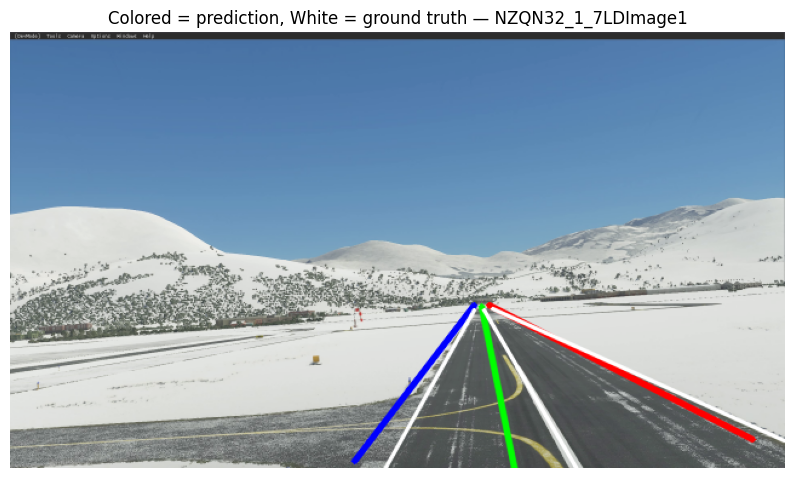

In [ ]:
#TO CHECK ON RANDOM IMAGES FROM VALIDATION DATASET THAT HOW FAR WE FROM REAL RUNWAY
import random

idx = random.randrange(len(val_dataset))
_, _, anchors_gt_norm, name = val_dataset[idx]
img_path = image_stem_to_path[name]

gt_orig = cv2.imread(img_path)
h, w = gt_orig.shape[:2]
gt_px = anchors_gt_norm.numpy().copy()
gt_px[0::2] *= w
gt_px[1::2] *= h

output, anchors_px, seg_mask = detect_runway(img_path, model, verbose=True)

def draw_gt(img, pt):
    x1, y1, x2, y2 = [int(v) for v in pt]
    cv2.line(img, (x1, y1), (x2, y2), (255, 255, 255), 2, cv2.LINE_AA)

draw_gt(output, gt_px[0:4]); draw_gt(output, gt_px[4:8]); draw_gt(output, gt_px[8:12])

plt.figure(figsize=(10, 6))
plt.imshow(output)
plt.title(f"Colored = prediction, White = ground truth — {name}")
plt.axis('off')
plt.show()